# Tesla Vehicle Deliveries — Case Study (Simple Version)
### Alpha Kappa Psi Fall 2026 Rush — Case Study #2: Business Analytics & AI

**Purpose:** Answer the Level 1-3 case-study questions using basic `pandas` and `matplotlib` — plain code, one chart per cell, no custom styling. This is the beginner-friendly companion to `tesla_case_study.ipynb`, which covers the same questions with more polished/advanced code.

**Dataset:** [Tesla Vehicle Deliveries Dataset (2012-2024) — Kaggle](https://www.kaggle.com/datasets/khushikyad001/tesla-vehicle-deliveries-dataset-20122024) — the Kaggle page labels this **realistic synthetic data for data science projects**, not Tesla's actual reported figures. So the numbers below illustrate the *techniques*, not Tesla's real sales history.

---
## 0. Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('tesla_vehicle_deliveries.csv')
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

Rows: 3000, Columns: 24


,Year,Quarter,Region,Model,Units Delivered,Average Price (USD),Production Delay (Days),Battery Type,Drive Type,Color,...,Avg Customer Rating,Warranty (Years),Number of Recalls,Software Version,Autopilot Enabled,Total Miles Driven,Update Frequency (Per Year),Battery Replacement Rate,Service Visits (Per Year),Resale Value (%)
0,2022,Q1,North America,Semi,2303,55815.81,8,Performance,AWD,Green,...,3.64,5,0,2024.40,False,1949189,9,0.0630,2.12,60.19
1,2024,Q2,Australia,Model X,2326,48215.76,48,Long Range,AWD,Red,...,3.90,4,3,2024.20,False,761023,10,0.0364,1.76,86.56
2,2017,Q2,North America,Model S,1916,100710.81,5,Standard,AWD,Blue,...,4.06,5,2,2020.10,True,4580690,5,0.0247,1.26,89.69
3,2022,Q2,Asia,Model S,1926,104853.22,51,Long Range,RWD,White,...,4.58,5,3,2023.11,False,1298493,6,0.0226,1.99,76.17
4,2023,Q4,South America,Model Y,3015,53642.26,8,Performance,RWD,Red,...,4.69,8,0,2023.70,False,4538532,6,0.0974,2.22,60.34


---
## 1. Look at the data before doing anything else

In [2]:
df.dtypes

Year                             int64
Quarter                            str
Region                             str
Model                              str
Units Delivered                  int64
Average Price (USD)            float64
Production Delay (Days)          int64
Battery Type                       str
Drive Type                         str
Color                              str
Range (KM)                       int64
Charging Time (Min)              int64
Efficiency (kWh/100km)         float64
CO2 Saved (Tons)               float64
Avg Customer Rating            float64
Warranty (Years)                 int64
Number of Recalls                int64
Software Version               float64
Autopilot Enabled                 bool
Total Miles Driven               int64
Update Frequency (Per Year)      int64
Battery Replacement Rate       float64
Service Visits (Per Year)      float64
Resale Value (%)               float64
dtype: object

In [3]:
df.isnull().sum()

Year                           0
Quarter                        0
Region                         0
Model                          0
Units Delivered                0
Average Price (USD)            0
Production Delay (Days)        0
Battery Type                   0
Drive Type                     0
Color                          0
Range (KM)                     0
Charging Time (Min)            0
Efficiency (kWh/100km)         0
CO2 Saved (Tons)               0
Avg Customer Rating            0
Warranty (Years)               0
Number of Recalls              0
Software Version               0
Autopilot Enabled              0
Total Miles Driven             0
Update Frequency (Per Year)    0
Battery Replacement Rate       0
Service Visits (Per Year)      0
Resale Value (%)               0
dtype: int64

In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Level 1 — Q1: Why does data cleaning matter?

**Data cleaning** means checking a dataset for missing values, duplicate rows, wrong data types, and values that don't make real-world sense — *before* using it to answer a business question. If you skip this step, a chart or average can look perfectly normal while actually being wrong.

**On this dataset:** there are no missing values and no duplicate rows, which is a good sign. But "no missing values" doesn't automatically mean the data is trustworthy — you also have to check whether the values make sense. For example, below we check whether any model shows deliveries before it was actually launched.

In [5]:
launch_year = {'Model S': 2012, 'Model X': 2015, 'Model 3': 2017,
               'Model Y': 2020, 'Semi': 2022, 'Cybertruck': 2023}

df['Launch Year'] = df['Model'].map(launch_year)
too_early = df[df['Year'] < df['Launch Year']]
print(f"Rows where a model appears before its real launch year: {len(too_early)}")
too_early[['Year', 'Model', 'Launch Year']].head()

Rows where a model appears before its real launch year: 1341


,Year,Model,Launch Year
6,2013,Model 3,2017
8,2015,Model 3,2017
9,2015,Cybertruck,2023
12,2017,Model Y,2020
14,2016,Cybertruck,2023


This is exactly the kind of problem data cleaning is meant to catch — the totals below would be somewhat misleading if we didn't know about it. For simplicity, the rest of this notebook keeps all rows (the case study is about practicing the techniques), but a real analysis would decide whether to drop, fix, or flag these rows first.

---
## 2. Choosing the right chart (Level 1 — Q2)

Different chart types answer different questions:
- **Bar chart** — compare a total across a few categories (e.g., total deliveries per model)
- **Line chart** — show how a number changes over time
- **Histogram** — show the shape/spread of one numeric column
- **Scatter plot** — check whether two numeric columns move together
- **Heatmap** — see many correlations at once

Below, each one is built one at a time.

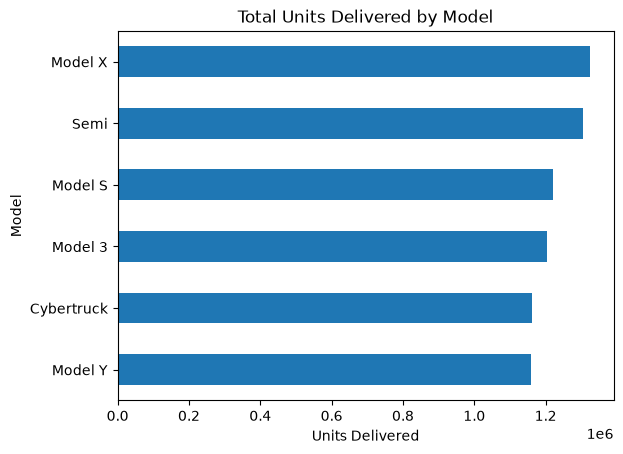

In [6]:
# Bar chart: total deliveries by model
by_model = df.groupby('Model')['Units Delivered'].sum().sort_values()

by_model.plot(kind='barh')
plt.title('Total Units Delivered by Model')
plt.xlabel('Units Delivered')
plt.show()

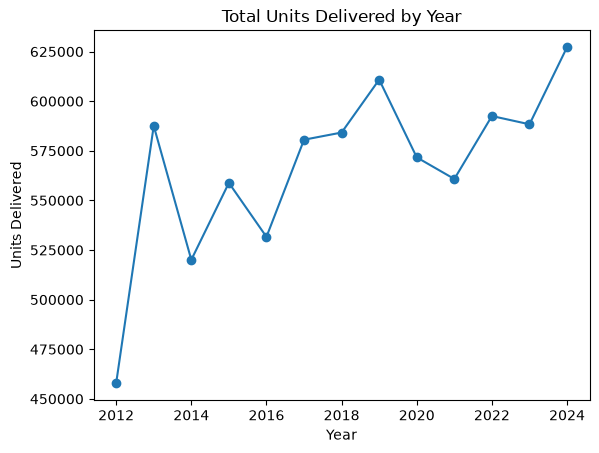

In [7]:
# Line chart: total deliveries by year
by_year = df.groupby('Year')['Units Delivered'].sum()

by_year.plot(kind='line', marker='o')
plt.title('Total Units Delivered by Year')
plt.xlabel('Year')
plt.ylabel('Units Delivered')
plt.show()

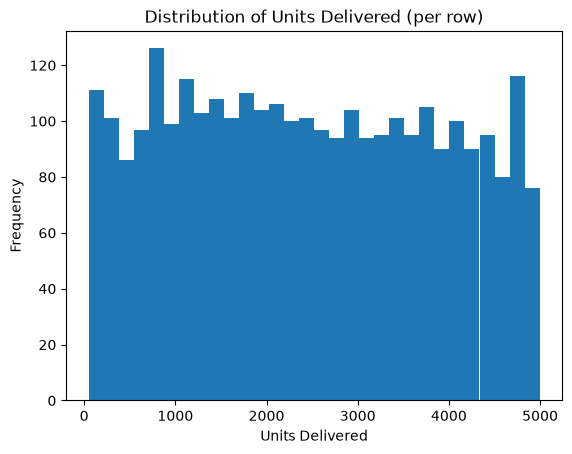

In [8]:
# Histogram: distribution of units delivered per row
df['Units Delivered'].plot(kind='hist', bins=30)
plt.title('Distribution of Units Delivered (per row)')
plt.xlabel('Units Delivered')
plt.show()

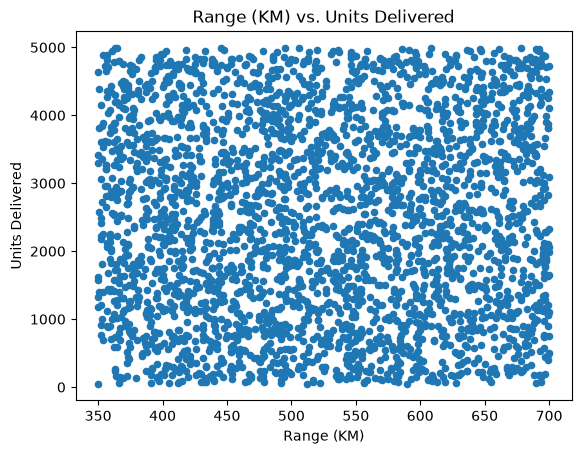

In [9]:
# Scatter plot: range vs. units delivered
df.plot(kind='scatter', x='Range (KM)', y='Units Delivered')
plt.title('Range (KM) vs. Units Delivered')
plt.show()

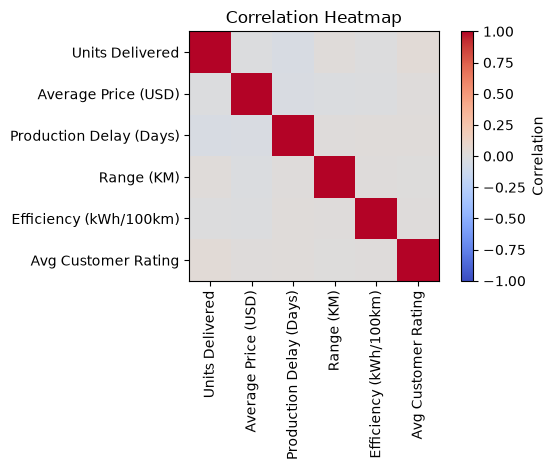

,Units Delivered,Average Price (USD),Production Delay (Days),Range (KM),Efficiency (kWh/100km),Avg Customer Rating
Units Delivered,1.000000,-0.014662,-0.043004,0.018262,-0.003141,0.035018
Average Price (USD),-0.014662,1.000000,-0.032845,-0.015994,-0.009211,0.009103
Production Delay (Days),-0.043004,-0.032845,1.000000,0.012522,0.020055,0.020321
Range (KM),0.018262,-0.015994,0.012522,1.000000,0.010998,0.002586
Efficiency (kWh/100km),-0.003141,-0.009211,0.020055,0.010998,1.000000,0.008810
Avg Customer Rating,0.035018,0.009103,0.020321,0.002586,0.008810,1.000000


In [10]:
# Heatmap-style correlation table (no seaborn needed)
numeric_cols = ['Units Delivered', 'Average Price (USD)', 'Production Delay (Days)',
                 'Range (KM)', 'Efficiency (kWh/100km)', 'Avg Customer Rating']
corr = df[numeric_cols].corr()

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar(label='Correlation')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr

---
## 3. Level 2 — Q1: Top 3 Tesla models by delivery volume

In [11]:
model_totals = df.groupby('Model')['Units Delivered'].sum().sort_values(ascending=False)
print(model_totals)

top3 = model_totals.head(3)
print("\nTop 3 models:", list(top3.index))

Model
Model X       1324414
Semi          1303940
Model S       1220201
Model 3       1202901
Cybertruck    1162010
Model Y       1158845
Name: Units Delivered, dtype: int64

Top 3 models: ['Model X', 'Semi', 'Model S']


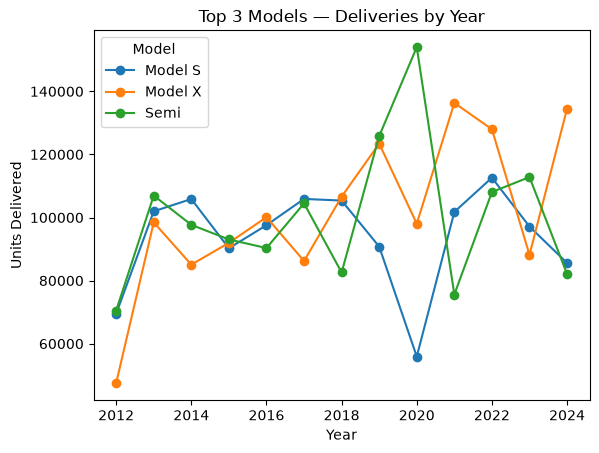

In [12]:
# How have the top 3 models trended over time?
top3_df = df[df['Model'].isin(top3.index)]
trend = top3_df.groupby(['Year', 'Model'])['Units Delivered'].sum().unstack('Model')

trend.plot(kind='line', marker='o')
plt.title('Top 3 Models — Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Units Delivered')
plt.show()

The top 3 models by total volume are generally the mass-market, longer-running model lines. That lines up with the real world: cars that have been in production longer and are priced for a bigger market tend to rack up more total deliveries than newer or niche vehicles.

---
## 4. Level 2 — Q3 & Level 3 — Q1: Does range or efficiency predict delivery volume?

In [13]:
print("Correlation between Range (KM) and Units Delivered:",
      round(df['Range (KM)'].corr(df['Units Delivered']), 3))

print("Correlation between Efficiency (kWh/100km) and Units Delivered:",
      round(df['Efficiency (kWh/100km)'].corr(df['Units Delivered']), 3))

Correlation between Range (KM) and Units Delivered: 0.018
Correlation between Efficiency (kWh/100km) and Units Delivered: -0.003


A correlation near 0 means the two numbers don't move together. Here, both values are close to 0, which means: **a vehicle having a longer range or better efficiency doesn't, by itself, predict how many units get delivered.** That suggests delivery volume is driven more by *which model and region* a vehicle belongs to (production capacity, price, market size) than by its spec sheet.

---
## 5. Level 2 — Q2: Which regions are growing fastest? (simple trend, not ML)

You don't need machine learning to spot a trend — comparing each region's first-year and last-year totals is a simple, transparent way to see which one is growing fastest.

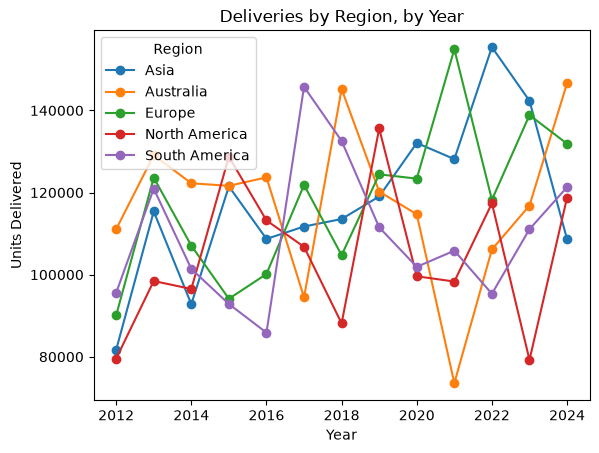

In [14]:
region_year = df.groupby(['Region', 'Year'])['Units Delivered'].sum().reset_index()

region_year.pivot(index='Year', columns='Region', values='Units Delivered').plot(marker='o')
plt.title('Deliveries by Region, by Year')
plt.xlabel('Year')
plt.ylabel('Units Delivered')
plt.show()

In [15]:
growth = []
for region, sub in region_year.groupby('Region'):
    sub = sub.sort_values('Year')
    first = sub['Units Delivered'].iloc[0]
    last = sub['Units Delivered'].iloc[-1]
    pct_change = (last - first) / first * 100
    growth.append({'Region': region, 'First Year Deliveries': first,
                    'Last Year Deliveries': last, 'Change (%)': round(pct_change, 1)})

growth_df = pd.DataFrame(growth).sort_values('Change (%)', ascending=False)
growth_df

,Region,First Year Deliveries,Last Year Deliveries,Change (%)
3,North America,79543,118776,49.3
2,Europe,90069,131887,46.4
0,Asia,81677,108625,33.0
1,Australia,111055,146636,32.0
4,South America,95576,121315,26.9


The region at the top of this table grew the fastest from its first year in the data to its last year — that's the one a simple trend-based read would flag as most likely to keep growing.

---
## 6. Level 3 — Q3 & Q4: A supply chain recommendation

In [16]:
region_delay = df.groupby('Region')['Production Delay (Days)'].mean().sort_values(ascending=False)
region_delay

Region
Asia             30.786441
North America    30.495622
South America    30.479239
Europe           30.107981
Australia        29.413183
Name: Production Delay (Days), dtype: float64

In [17]:
summary = growth_df.merge(region_delay.rename('Avg Production Delay (Days)'), on='Region')
summary = summary.sort_values('Change (%)', ascending=False)
summary

,Region,First Year Deliveries,Last Year Deliveries,Change (%),Avg Production Delay (Days)
0,North America,79543,118776,49.3,30.495622
1,Europe,90069,131887,46.4,30.107981
2,Asia,81677,108625,33.0,30.786441
3,Australia,111055,146636,32.0,29.413183
4,South America,95576,121315,26.9,30.479239


**Opportunity:** the region combining **high growth** (top of the `Change (%)` column) with **high production delay** (top of the `Avg Production Delay (Days)` column) is the one leaving the most growth on the table — demand is there, but deliveries are getting held up.

**Recommended strategy:** for that region, prioritize local production/assembly capacity or parts buffering (safety stock for the components most linked to delay) rather than a company-wide fix. This targets the actual bottleneck — execution, not demand — and is supported directly by the growth and delay numbers above.

---
## 7. Level 1 — Q3: Why do dashboards and real-time reporting help?

The tables and charts above are a small example of the answer:

- **Speed:** instead of scrolling through 3,000 rows, a manager can look at a handful of grouped numbers (totals by model, by year, by region) and immediately see what's going on.
- **Consistent definitions:** once "top 3 models" or "fastest-growing region" is defined one way, everyone on a team can use the same definition instead of arguing about whose spreadsheet is right.
- **From monitoring to action:** a real-time dashboard doesn't just show a number went up or down — paired with a simple rule (like the growth + delay table above), it can point straight at *what to do about it*.

---
## 8. Summary

Same case-study questions as `tesla_case_study.ipynb`, answered with plain `pandas` groupbys, `.corr()`, and default `matplotlib` charts — no custom styling, no external stats libraries, one chart per cell. The goal here is that every line of code is easy to read and explain, not to produce a polished dashboard.